In [1]:
import numpy as np
import numpy as np
import os
os.environ["picaso_refdata"]="/Users/ihuckabee/Documents/picaso-master/reference"
os.environ['PYSYN_CDBS']="/Users/ihuckabee/Documents/picaso-master/grp/redcat/trds"
refdata = os.getenv("picaso_refdata")
import pdb
from virga import justdoit as vdi
import pandas as pd
import astropy.units as u
from picaso import justplotit as ppi
from picaso import justdoit as pdi
import pandas as pd
#import xesmf as xe
import xarray as xr
from bokeh.plotting import show, figure

In [ ]:
wave_range=[0.3,2.5]
opacity = pdi.opannection(wave_range)
opa = pdi.opannection(wave_range=wave_range)
neptune = pdi.inputs()
neptune.phase_angle(0, num_gangle=3, num_tangle=3) #radians
neptune.gravity(gravity=11.15, gravity_unit=pdi.u.Unit('m/(s**2)')) #any astropy units available
neptune.star(opacity, temp=5778, metal=0.00, logg=4.4374, radius=1.0, radius_unit=pdi.u.R_sun )#opacity db, pysynphot database, temp, metallicity, logg
neptune.atmosphere(filename="/Users/ihuckabee/Documents/picaso-master/nepforpicaso_salr.txt", delim_whitespace=True)
df = neptune.spectrum(opacity)

Turning off Raman for Non-H2 atmosphere


In [ ]:
f = open("/Users/ihuckabee/Documents/picaso-master/nepforpicaso_salr.txt",'r')
lines = f.readlines()[1:]
pressure = []
temp = []
for i in range(len(lines)):
        pressure.append(float(lines[i].split()[0]))
        temp.append(float(lines[i].split()[1]))

In [15]:
pres = np.array(pressure)
lon = np.linspace(-180,180,32)
lat = np.linspace(-90,90,16)
nep_data = np.array(temp)*np.ones((len(lon),len(lat),len(temp)))
np.shape(nep_data)

(32, 16, 999)

In [5]:
df_all = pd.read_csv('/Users/ihuckabee/Documents/picaso-master/cloudall.csv')
df_1 = pd.read_csv('/Users/ihuckabee/Documents/picaso-master/cloud1.csv')
df_2 = pd.read_csv('/Users/ihuckabee/Documents/picaso-master/cloud2.csv')
df_31 = pd.read_csv('/Users/ihuckabee/Documents/picaso-master/cloud31.csv')
df_4 = pd.read_csv('/Users/ihuckabee/Documents/picaso-master/cloud4.csv')
df_32 = pd.read_csv('/Users/ihuckabee/Documents/picaso-master/cloud32.csv')

In [16]:
wno_grid = np.load("wnogrid.npy")
#opd = np.array(df_all["opd"])*np.ones((len(lon), len(lat),len(pres), len(wno)))

#wno, alb, fpfs = df['wavenumber'] , df['albedo'] , df['fpfs_reflected']
#wno, alb = pdi.mean_regrid(wno, alb , R=100)

In [18]:
fake_opd = np.zeros((len(lon), len(lat),len(pres), len(wno_grid))) # create fake data
where_lat = np.where(((lat>-50) & (lat<50)))#creating a grey cloud band
where_pres = np.where(((pres<0.01) & (pres>.001)))#creating a grey cloud band
for il in where_lat[0]:
    for ip in where_pres[0]:
        fake_opd[:,il,ip,:]=10 #optical depth of 10 (>>1)

#make up asymmetry and single scattering properties
fake_asymmetry_g0 = 0.8+ np.zeros((len(lon), len(lat),len(pres), len(wno_grid)))
fake_ssa_w0 = 0.9+ np.zeros((len(lon), len(lat),len(pres), len(wno_grid)))


(128, 64, 999, 213)

ValueError: Variable 'opd': Could not convert tuple of form (dims, data[, attrs, encoding]): (['lon', 'lat', 'pressure', 'wno'], 0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
23947    0.0
23948    0.0
23949    0.0
23950    0.0
23951    0.0
Name: opd, Length: 23952, dtype: float64, {'units': 'depth per layer'}) to Variable.

In [18]:
# create coords
#pdb.set_trace()
# put data into a dataset
ds = xr.Dataset(
    data_vars=dict(
        temperature=(["lon", "lat","pressure"], nep_data,{'units': 'Kelvin'})#, required
        #kzz = (["x", "y","z"], gcm_out['kzz'])#could add other data components if wanted
    ),
    coords=dict(
        lon=(["lon"], lon,{'units': 'degrees'}),#required
        lat=(["lat"], lat,{'units': 'degrees'}),#required
        pressure=(["pressure"], pres,{'units': 'bar'})#required*
    ),
    attrs=dict(description="coords with vectors"),
)
                
n_gauss_angles =3
n_chebychev_angles=3

gangle, gweight, tangle, tweight = pdi.get_angles_3d(n_gauss_angles, n_chebychev_angles)
ubar0, ubar1, cos_theta, latitude, longitude = pdi.compute_disco(n_gauss_angles, n_chebychev_angles, gangle, tangle, phase_angle=0)

verbose=True;regrid=True; Regridding 3D output to ngangle=3, ntangle=3, with phase=0.
verbose=True;Only one data variable included. Make sure to add in chemical abundances before trying to run spectra.


/Users/ihuckabee/anaconda3/envs/xesmf_env/lib/python3.12/site-packages/xesmf/smm.py:130: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


ValueError: Invalid object to show. The object to passed to show must be one of:

* a UIElement (e.g. a plot, figure, widget or layout)
* a Bokeh Application
* a callable suitable to an application FunctionHandler


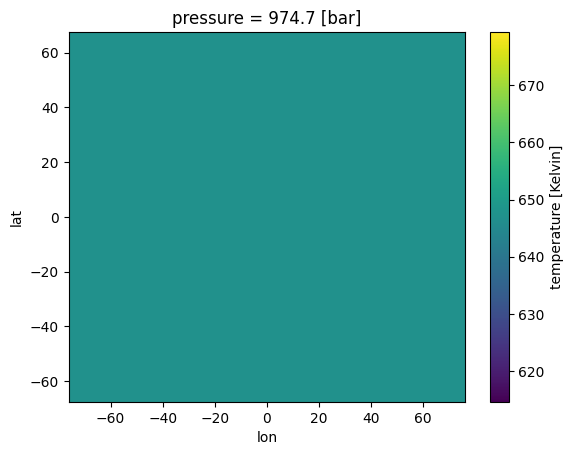

In [19]:
#regrid is True as you will do it within the function
nep3d = neptune.atmosphere_3d(ds,regrid=True,plot=True,verbose=True)
show(nep3d)

In [23]:
out3d = neptune.spectrum(opacity,calculation='reflected',dimension='3d',full_output=True)
#wno,fpfs = pdi.mean_regrid(out3d['wavenumber'],out3d['fpfs_thermal'],R=100)
#ppi.show(ppi.spectrum(wno, fpfs*1e6, plot_width=500,y_axis_type='log'))

/Users/ihuckabee/Documents/picaso-master/picaso/justdoit.py:1977: SyntaxWarning: invalid escape sequence '\s'
  ptchem = pd.read_csv(os.path.join(sonora_path,build_filename),sep='\s+',compression='gzip')
/Users/ihuckabee/Documents/picaso-master/picaso/justdoit.py:2060: SyntaxWarning: invalid escape sequence '\s'
  grid = pd.read_csv(filename,sep='\s+')
/Users/ihuckabee/Documents/picaso-master/picaso/justdoit.py:2123: SyntaxWarning: invalid escape sequence '\s'
  a = pd.read_csv(filename,sep='\s+',skiprows=1,header=None, names=cols)
/Users/ihuckabee/Documents/picaso-master/picaso/justdoit.py:4267: SyntaxWarning: invalid escape sequence '\s'
  threed_grid = pd.read_csv(input_file,sep='\s+',names=['p','t','k'])
/Users/ihuckabee/Documents/picaso-master/picaso/justdoit.py:4391: SyntaxWarning: invalid escape sequence '\s'
  skiprows=12,sep='\s+',
/Users/ihuckabee/Documents/picaso-master/picaso/justdoit.py:4395: SyntaxWarning: invalid escape sequence '\s'
  skiprows=12,sep='\s+',
/Users/ihuck

IndexError: index 0 is out of bounds for axis 0 with size 0

In [22]:
ppi.disco(out3d['full_output'] ,wavelength=[1.1, 1.4], calculation='thermal')

NameError: name 'out3d' is not defined